# SSFD EDA, Preprocessing, and Model-Oriented Visualization

This notebook explores the `S-FFSD 3.csv` dataset and prepares three downstream paths:

- `LightGBM`: transaction-level tabular modeling
- `Heterogeneous GNN`: entity and relation graph modeling
- `Event-Based GNN`: time-ordered event graph modeling

The notebook is written to be practical first: profile the raw data, inspect label behavior, engineer baseline features, and produce graph tables that can be consumed later by graph libraries such as PyTorch Geometric or DGL.

## 1. Setup

In [1]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 100)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "S-FFSD 3.csv"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

INTERIM_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")

Project root: /Users/dienmayhaituyet/Documents/DataMining/COMP4040_Team12_FraudDetection
Dataset path: /Users/dienmayhaituyet/Documents/DataMining/COMP4040_Team12_FraudDetection/data/raw/S-FFSD 3.csv


## 2. Load data and inspect the raw schema

In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,Time,Source,Target,Amount,Location,Type,Labels
0,0,S10000,T1000,13.74,L100,TP100,2
1,1,S10001,T1001,73.17,L101,TP101,2
2,2,S10002,T1000,68.59,L100,TP100,2
3,3,S10003,T1002,57.00,L100,TP102,2
4,4,S10004,T1000,11.55,L100,TP100,2


In [3]:
print("Shape:", df.shape)
display(df.info())
display(df.describe(include="all").T)

Shape: (77881, 7)
<class 'pandas.DataFrame'>
RangeIndex: 77881 entries, 0 to 77880
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Time      77881 non-null  int64  
 1   Source    77881 non-null  str    
 2   Target    77881 non-null  str    
 3   Amount    77881 non-null  float64
 4   Location  77881 non-null  str    
 5   Type      77881 non-null  str    
 6   Labels    77881 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 5.6 MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Time,77881.0,NaN,NaN,NaN,38940.0,22482.452494,0.0,19470.0,38940.0,58410.0,77880.0
Source,77881,30346,S11166,1533,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Target,77881,886,T1023,15279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount,77881.0,NaN,NaN,NaN,195.624898,4642.50852,0.0,5.0,16.61,69.0,800000.0
Location,77881,296,L100,48784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,77881,166,TP100,17911,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Labels,77881.0,NaN,NaN,NaN,1.306249,0.915825,0.0,0.0,2.0,2.0,2.0


In [4]:
missing_summary = df.isna().sum().to_frame("missing_count")
missing_summary["missing_ratio"] = missing_summary["missing_count"] / len(df)
missing_summary

,missing_count,missing_ratio
Time,0,0.0
Source,0,0.0
Target,0,0.0
Amount,0,0.0
Location,0,0.0
Type,0,0.0
Labels,0,0.0


## 3. Basic cleaning and type normalization

This dataset is already compact and clean. The main work here is making categorical IDs explicit and sorting by time.

In [5]:
df = df.rename(columns={col: col.strip() for col in df.columns})

df["Time"] = pd.to_numeric(df["Time"], errors="coerce").astype("Int64")
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")
df["Labels"] = pd.to_numeric(df["Labels"], errors="coerce").astype("Int64")

categorical_cols = ["Source", "Target", "Location", "Type"]
for col in categorical_cols:
    df[col] = df[col].astype("string")

df = df.sort_values("Time").reset_index(drop=True)
df["event_index"] = np.arange(len(df))

df.head()

,Time,Source,Target,Amount,Location,Type,Labels,event_index
0,0,S10000,T1000,13.74,L100,TP100,2,0
1,1,S10001,T1001,73.17,L101,TP101,2,1
2,2,S10002,T1000,68.59,L100,TP100,2,2
3,3,S10003,T1002,57.00,L100,TP102,2,3
4,4,S10004,T1000,11.55,L100,TP100,2,4


## 4. Label distribution and class balance

,count,ratio
Labels,,
0,24387,0.3131
1,5256,0.0675
2,48238,0.6194


/var/folders/st/3lhx8lh109n5pxkwk6s4s6040000gn/T/ipykernel_3491/1513640084.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Labels", order=sorted(df["Labels"].dropna().unique()), palette="viridis")


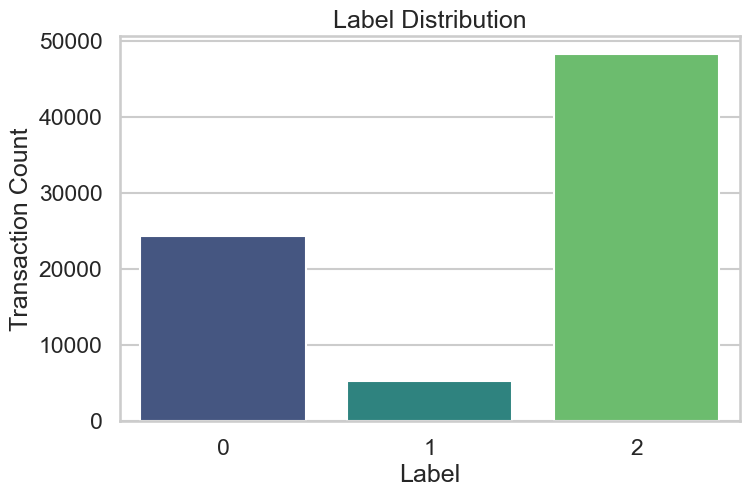

In [6]:
label_counts = df["Labels"].value_counts().sort_index()
label_ratio = (label_counts / len(df)).round(4)
display(pd.DataFrame({"count": label_counts, "ratio": label_ratio}))

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Labels", order=sorted(df["Labels"].dropna().unique()), palette="viridis")
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Transaction Count")
plt.show()

## 5. Univariate EDA

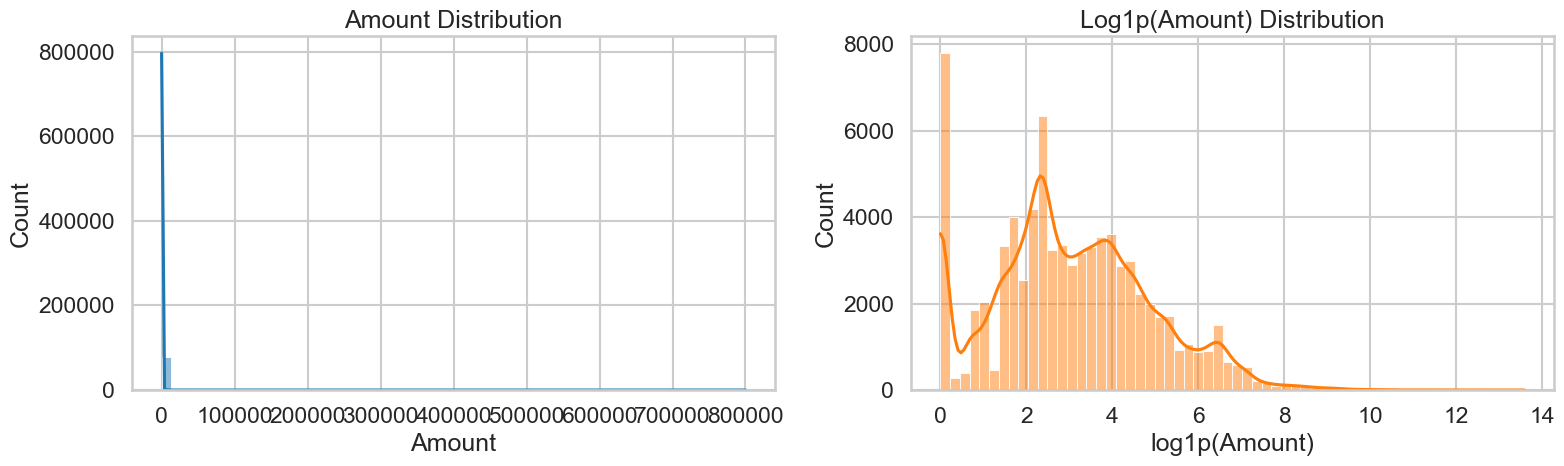

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df["Amount"], bins=60, kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("Amount Distribution")

sns.histplot(np.log1p(df["Amount"]), bins=60, kde=True, ax=axes[1], color="#ff7f0e")
axes[1].set_title("Log1p(Amount) Distribution")
axes[1].set_xlabel("log1p(Amount)")

plt.tight_layout()
plt.show()

/var/folders/st/3lhx8lh109n5pxkwk6s4s6040000gn/T/ipykernel_3491/925948406.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Labels", y="Amount", palette="Set2")


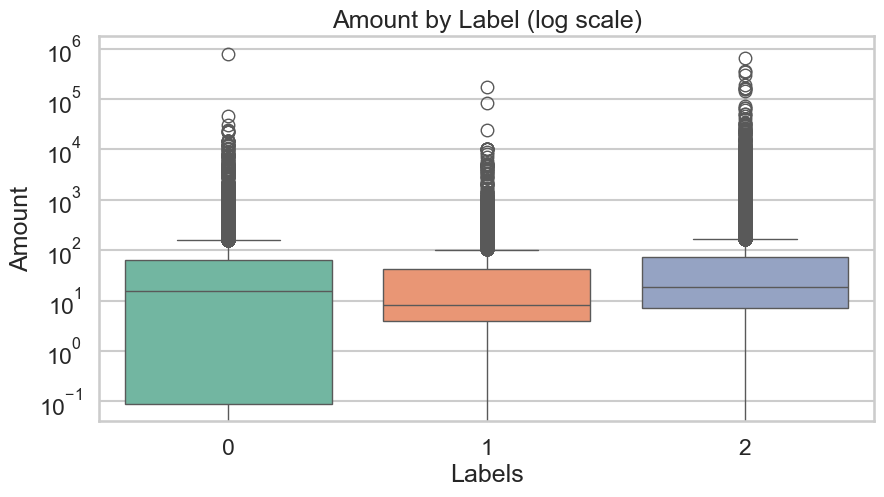

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Labels", y="Amount", palette="Set2")
plt.yscale("log")
plt.title("Amount by Label (log scale)")
plt.show()

,unique_count
Source,30346
Target,886
Location,296
Type,166


/var/folders/st/3lhx8lh109n5pxkwk6s4s6040000gn/T/ipykernel_3491/830402529.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cardinality.index, y=cardinality.values, palette="mako")


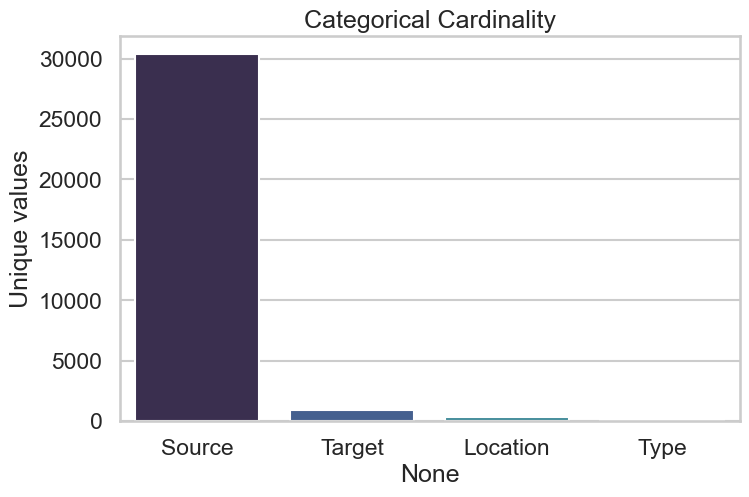

In [9]:
cardinality = pd.Series({
    "Source": df["Source"].nunique(),
    "Target": df["Target"].nunique(),
    "Location": df["Location"].nunique(),
    "Type": df["Type"].nunique(),
}).sort_values(ascending=False)

display(cardinality.to_frame("unique_count"))

plt.figure(figsize=(8, 5))
sns.barplot(x=cardinality.index, y=cardinality.values, palette="mako")
plt.title("Categorical Cardinality")
plt.ylabel("Unique values")
plt.show()

## 6. Temporal EDA

`Time` behaves like an event order index, which is useful for sequential and event-graph models.

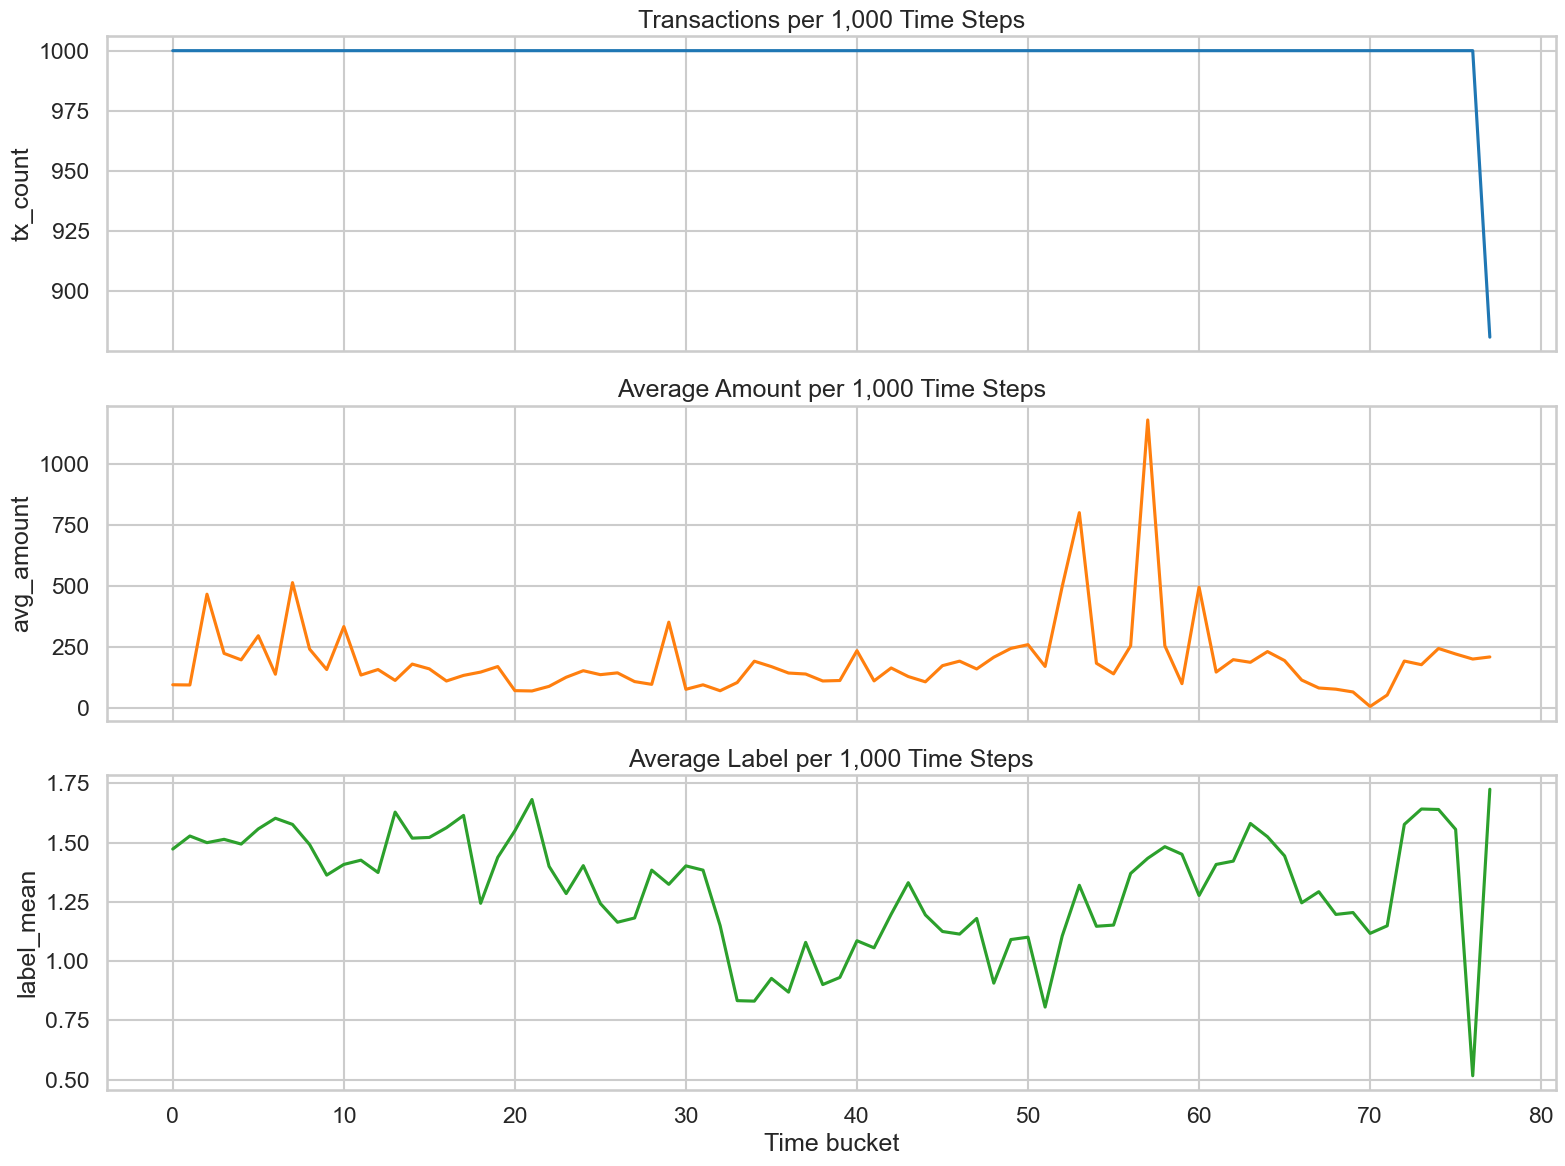

In [10]:
window = 1000
timeline = df.groupby(df["Time"] // window).agg(
    tx_count=("Time", "size"),
    avg_amount=("Amount", "mean"),
    label_mean=("Labels", "mean"),
).reset_index().rename(columns={"Time": "time_bucket"})

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
sns.lineplot(data=timeline, x=timeline.index, y="tx_count", ax=axes[0], color="#1f77b4")
axes[0].set_title("Transactions per 1,000 Time Steps")

sns.lineplot(data=timeline, x=timeline.index, y="avg_amount", ax=axes[1], color="#ff7f0e")
axes[1].set_title("Average Amount per 1,000 Time Steps")

sns.lineplot(data=timeline, x=timeline.index, y="label_mean", ax=axes[2], color="#2ca02c")
axes[2].set_title("Average Label per 1,000 Time Steps")
axes[2].set_xlabel("Time bucket")

plt.tight_layout()
plt.show()

In [11]:
label_timeline = (
    df.groupby([df["Time"] // window, "Labels"])
    .size()
    .reset_index(name="count")
    .rename(columns={"Time": "time_bucket"})
)

plt.figure(figsize=(16, 6))
sns.lineplot(data=label_timeline, x="Time", y="count", hue="Labels", palette="tab10")
plt.title("Label Counts Over Time")
plt.xlabel("Time bucket (1,000-step windows)")
plt.ylabel("Count")
plt.show()

ValueError: Could not interpret value `Time` for `x`. An entry with this name does not appear in `data`.

<Figure size 1600x600 with 0 Axes>

## 7. Interaction and category-level EDA

In [ ]:
top_types = df["Type"].value_counts().head(15).index
plt.figure(figsize=(14, 6))
sns.countplot(data=df[df["Type"].isin(top_types)], x="Type", hue="Labels", order=top_types, palette="Set2")
plt.title("Top 15 Transaction Types by Label")
plt.xticks(rotation=45)
plt.show()

In [ ]:
top_locations = df["Location"].value_counts().head(15).index
location_label_share = (
    df[df["Location"].isin(top_locations)]
    .groupby(["Location", "Labels"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(14, 6))
sns.barplot(data=location_label_share, x="Location", y="count", hue="Labels", palette="Spectral")
plt.title("Top 15 Locations by Label")
plt.xticks(rotation=45)
plt.show()

In [ ]:
cross_tab = pd.crosstab(df["Type"], df["Labels"])
top_cross_tab = cross_tab.loc[df["Type"].value_counts().head(20).index]

plt.figure(figsize=(12, 8))
sns.heatmap(top_cross_tab, cmap="YlGnBu")
plt.title("Type vs Label Heatmap (Top 20 Types)")
plt.show()

## 8. Repeated-entity behavior

These plots help assess whether graph methods are likely to add value.

In [ ]:
source_freq = df["Source"].value_counts()
target_freq = df["Target"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(source_freq, bins=60, ax=axes[0], color="#4c72b0")
axes[0].set_title("Transactions per Source")
axes[0].set_yscale("log")

sns.histplot(target_freq, bins=60, ax=axes[1], color="#dd8452")
axes[1].set_title("Transactions per Target")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

In [ ]:
entity_label_mix = (
    df.groupby("Source")["Labels"]
    .nunique()
    .value_counts()
    .sort_index()
)

display(entity_label_mix.to_frame("source_count"))

plt.figure(figsize=(8, 5))
sns.barplot(x=entity_label_mix.index.astype(str), y=entity_label_mix.values, palette="crest")
plt.title("How Many Distinct Labels Appear per Source?")
plt.xlabel("Distinct labels seen for a Source")
plt.ylabel("Number of Sources")
plt.show()

## 9. Transaction-level feature engineering for LightGBM

The first baseline should be a fast tabular model. This section creates features that are available at decision time.

In [ ]:
tabular_df = df.copy()

tabular_df["amount_log1p"] = np.log1p(tabular_df["Amount"])
tabular_df["source_tx_count_so_far"] = tabular_df.groupby("Source").cumcount()
tabular_df["target_tx_count_so_far"] = tabular_df.groupby("Target").cumcount()
tabular_df["location_tx_count_so_far"] = tabular_df.groupby("Location").cumcount()
tabular_df["type_tx_count_so_far"] = tabular_df.groupby("Type").cumcount()

tabular_df["prev_time_by_source"] = tabular_df.groupby("Source")["Time"].shift(1)
tabular_df["prev_time_by_target"] = tabular_df.groupby("Target")["Time"].shift(1)
tabular_df["source_time_gap"] = tabular_df["Time"] - tabular_df["prev_time_by_source"]
tabular_df["target_time_gap"] = tabular_df["Time"] - tabular_df["prev_time_by_target"]

tabular_df["source_prev_amount"] = tabular_df.groupby("Source")["Amount"].shift(1)
tabular_df["source_amount_delta"] = tabular_df["Amount"] - tabular_df["source_prev_amount"]
tabular_df["source_amount_mean_so_far"] = (
    tabular_df.groupby("Source")["Amount"]
    .expanding()
    .mean()
    .reset_index(level=0, drop=True)
)

tabular_df["source_amount_mean_before_tx"] = (
    (tabular_df["source_amount_mean_so_far"] * (tabular_df["source_tx_count_so_far"] + 1) - tabular_df["Amount"])
    / tabular_df["source_tx_count_so_far"].replace(0, np.nan)
)
tabular_df["amount_vs_source_history"] = tabular_df["Amount"] - tabular_df["source_amount_mean_before_tx"]

fill_zero_cols = [
    "source_time_gap",
    "target_time_gap",
    "source_amount_delta",
    "amount_vs_source_history",
]
tabular_df[fill_zero_cols] = tabular_df[fill_zero_cols].fillna(0)

tabular_df[[
    "Time", "Source", "Target", "Amount", "Labels",
    "source_tx_count_so_far", "target_tx_count_so_far",
    "source_time_gap", "target_time_gap",
    "amount_vs_source_history"
]].head(10)

In [ ]:
lightgbm_features = [
    "Time",
    "Amount",
    "amount_log1p",
    "Source",
    "Target",
    "Location",
    "Type",
    "source_tx_count_so_far",
    "target_tx_count_so_far",
    "location_tx_count_so_far",
    "type_tx_count_so_far",
    "source_time_gap",
    "target_time_gap",
    "source_amount_delta",
    "amount_vs_source_history",
]

lightgbm_df = tabular_df[lightgbm_features + ["Labels"]].copy()
for col in ["Source", "Target", "Location", "Type"]:
    lightgbm_df[col] = lightgbm_df[col].astype("category")

lightgbm_df.head()

In [ ]:
numeric_feature_cols = [
    "Amount",
    "amount_log1p",
    "source_tx_count_so_far",
    "target_tx_count_so_far",
    "source_time_gap",
    "target_time_gap",
    "source_amount_delta",
    "amount_vs_source_history",
]

corr = lightgbm_df[numeric_feature_cols + ["Labels"]].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Baseline Numeric Feature Correlation")
plt.show()

## 10. Preprocessing outputs for LightGBM

In [ ]:
lightgbm_output_path = PROCESSED_DIR / "ssfd_lightgbm_features.csv"
lightgbm_df.to_csv(lightgbm_output_path, index=False)
print(f"Saved LightGBM-ready table to: {lightgbm_output_path}")

## 11. Heterogeneous graph construction

A heterogeneous GNN should model different node types explicitly: `Source`, `Target`, `Location`, and `Type`.

Useful relation types:
- `Source -> Target`
- `Source -> Location`
- `Source -> Type`
- `Target -> Location`
- `Target -> Type`

In [ ]:
def build_node_table(series, node_type):
    node_df = pd.DataFrame({"raw_id": pd.Index(series.dropna().unique(), dtype="object")})
    node_df = node_df.sort_values("raw_id").reset_index(drop=True)
    node_df[f"{node_type}_id"] = np.arange(len(node_df))
    return node_df[[f"{node_type}_id", "raw_id"]]

source_nodes = build_node_table(df["Source"], "source")
target_nodes = build_node_table(df["Target"], "target")
location_nodes = build_node_table(df["Location"], "location")
type_nodes = build_node_table(df["Type"], "type")

display(source_nodes.head())
display(target_nodes.head())

In [ ]:
source_map = dict(zip(source_nodes["raw_id"], source_nodes["source_id"]))
target_map = dict(zip(target_nodes["raw_id"], target_nodes["target_id"]))
location_map = dict(zip(location_nodes["raw_id"], location_nodes["location_id"]))
type_map = dict(zip(type_nodes["raw_id"], type_nodes["type_id"]))

hetero_events = df.copy()
hetero_events["source_id"] = hetero_events["Source"].map(source_map)
hetero_events["target_id"] = hetero_events["Target"].map(target_map)
hetero_events["location_id"] = hetero_events["Location"].map(location_map)
hetero_events["type_id"] = hetero_events["Type"].map(type_map)

edge_source_target = hetero_events[["source_id", "target_id", "Amount", "Time", "Labels"]].copy()
edge_source_location = hetero_events[["source_id", "location_id", "Amount", "Time", "Labels"]].copy()
edge_source_type = hetero_events[["source_id", "type_id", "Amount", "Time", "Labels"]].copy()
edge_target_location = hetero_events[["target_id", "location_id", "Amount", "Time", "Labels"]].copy()
edge_target_type = hetero_events[["target_id", "type_id", "Amount", "Time", "Labels"]].copy()

print("source-target edges:", edge_source_target.shape)
print("source-location edges:", edge_source_location.shape)
print("source-type edges:", edge_source_type.shape)

In [ ]:
graph_relation_counts = pd.Series({
    "source->target": len(edge_source_target),
    "source->location": len(edge_source_location),
    "source->type": len(edge_source_type),
    "target->location": len(edge_target_location),
    "target->type": len(edge_target_type),
})

plt.figure(figsize=(10, 5))
sns.barplot(x=graph_relation_counts.index, y=graph_relation_counts.values, palette="rocket")
plt.title("Heterogeneous Graph Relation Sizes")
plt.xticks(rotation=30)
plt.ylabel("Number of edges")
plt.show()

### Suggested heterogeneous GNN visuals

These charts are useful before training a hetero-GNN:

- relation-size bar chart
- node-type cardinality chart
- label distribution across high-degree nodes
- degree distribution per node type
- relation-specific amount distributions

In [ ]:
source_degree = edge_source_target.groupby("source_id").size()
target_degree = edge_source_target.groupby("target_id").size()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(source_degree, bins=50, ax=axes[0], color="#2ca02c")
axes[0].set_title("Source Degree Distribution")
axes[0].set_yscale("log")

sns.histplot(target_degree, bins=50, ax=axes[1], color="#d62728")
axes[1].set_title("Target Degree Distribution")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

## 12. Event-based graph construction

For an event-based GNN, treat each transaction as an event node and connect it to entities and optionally to nearby events in time.

In [ ]:
event_nodes = df[["event_index", "Time", "Amount", "Labels"]].copy()
event_nodes["amount_log1p"] = np.log1p(event_nodes["Amount"])

event_to_source = hetero_events[["event_index", "source_id"]].copy()
event_to_target = hetero_events[["event_index", "target_id"]].copy()
event_to_location = hetero_events[["event_index", "location_id"]].copy()
event_to_type = hetero_events[["event_index", "type_id"]].copy()

event_edges_temporal = event_nodes[["event_index", "Time"]].copy()
event_edges_temporal["next_event_index"] = event_edges_temporal["event_index"].shift(-1)
event_edges_temporal["next_time"] = event_edges_temporal["Time"].shift(-1)
event_edges_temporal["delta_t"] = event_edges_temporal["next_time"] - event_edges_temporal["Time"]
event_edges_temporal = event_edges_temporal.dropna().astype({"next_event_index": int, "next_time": int, "delta_t": int})

display(event_nodes.head())
display(event_edges_temporal.head())

In [ ]:
plt.figure(figsize=(14, 5))
sns.histplot(event_edges_temporal["delta_t"], bins=50, color="#9467bd")
plt.title("Time Gap Between Consecutive Events")
plt.xlabel("delta_t")
plt.show()

In [ ]:
event_label_flow = (
    df[["Labels"]]
    .assign(next_label=df["Labels"].shift(-1))
    .dropna()
    .groupby(["Labels", "next_label"])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(8, 6))
sns.heatmap(event_label_flow, annot=True, fmt=".0f", cmap="Blues")
plt.title("Label Transition Matrix for Consecutive Events")
plt.xlabel("Next event label")
plt.ylabel("Current event label")
plt.show()

### Suggested event-based GNN visuals

- event-to-event time gap distribution
- label transition matrix over consecutive events
- rolling label ratio over time
- temporal subgraph snapshots for anomaly windows
- event amount spikes around suspicious sequences

## 13. Save graph-ready artifacts

In [ ]:
source_nodes.to_csv(INTERIM_DIR / "ssfd_source_nodes.csv", index=False)
target_nodes.to_csv(INTERIM_DIR / "ssfd_target_nodes.csv", index=False)
location_nodes.to_csv(INTERIM_DIR / "ssfd_location_nodes.csv", index=False)
type_nodes.to_csv(INTERIM_DIR / "ssfd_type_nodes.csv", index=False)

edge_source_target.to_csv(INTERIM_DIR / "ssfd_edge_source_target.csv", index=False)
edge_source_location.to_csv(INTERIM_DIR / "ssfd_edge_source_location.csv", index=False)
edge_source_type.to_csv(INTERIM_DIR / "ssfd_edge_source_type.csv", index=False)
edge_target_location.to_csv(INTERIM_DIR / "ssfd_edge_target_location.csv", index=False)
edge_target_type.to_csv(INTERIM_DIR / "ssfd_edge_target_type.csv", index=False)

event_nodes.to_csv(INTERIM_DIR / "ssfd_event_nodes.csv", index=False)
event_to_source.to_csv(INTERIM_DIR / "ssfd_event_to_source.csv", index=False)
event_to_target.to_csv(INTERIM_DIR / "ssfd_event_to_target.csv", index=False)
event_to_location.to_csv(INTERIM_DIR / "ssfd_event_to_location.csv", index=False)
event_to_type.to_csv(INTERIM_DIR / "ssfd_event_to_type.csv", index=False)
event_edges_temporal.to_csv(INTERIM_DIR / "ssfd_event_temporal_edges.csv", index=False)

print("Saved LightGBM, hetero-graph, and event-graph artifacts.")

## 14. Notes for downstream modeling

### LightGBM
- Start with multiclass classification because `Labels` has three classes.
- Use time-aware splits rather than random splits.
- Treat `Source`, `Target`, `Location`, and `Type` as categorical features.

### Heterogeneous GNN
- Use separate node stores for each entity type.
- Attach edge attributes such as `Amount`, `Time`, and optionally transaction label.
- Predict either event labels or node-level suspiciousness depending on the target design.

### Event-based GNN
- Use event nodes with features such as `Amount`, `amount_log1p`, and local history features.
- Connect event nodes to entity nodes and to neighboring events in time.
- This design is useful when local temporal context matters more than static structure.